# Unit 4 — Notebook 2: Deploying and Scaling ML Containers with Kubernetes

**What you will learn:**
1. What problems Kubernetes (K8s) solves that Docker alone cannot
2. The key Kubernetes objects: Pod, Deployment, Service, HPA
3. How to write production-ready YAML manifests for an ML API
4. How to perform rolling updates and rollbacks with zero downtime

**Prerequisite:** Notebook 01 — you should have the `iris-api:v1` Docker image concept fresh in your mind.

**How to use:** `%%writefile` cells create real YAML files on disk. `subprocess` cells show `kubectl` commands — they run for real when a cluster is reachable; otherwise (kubectl missing, or installed with no cluster running) they print the expected output, clearly labeled.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 02 "02. Distributed Computing with Dask" — a scheduler placing work across many workers and surviving the loss of one; Kubernetes does that for whole containers of your API, with Deployments, Services and autoscalers as the controls.


## 📰 CrowdStrike, 19 July 2024: what happens without a staged rollout

At **04:09 UTC on 19 July 2024**, CrowdStrike pushed a configuration update — "Rapid Response Content", specifically **Channel File 291** — to its Falcon sensor. The file contained a template instance that caused an out-of-bounds memory read, which the sensor could not handle, which crashed Windows into a blue screen. Every Windows host running sensor 7.11 or later that was online between **04:09 and 05:27 UTC** was affected. CrowdStrike reverted the file at 05:27 — **78 minutes** — and this is the detail that matters most for this notebook: reverting did not fix the machines. A host stuck in a boot loop cannot download the corrected file. Recovery required physical or console access, machine by machine, across airlines, hospitals and banks.

Two lessons sit inside that timeline, and they are the two things Kubernetes gives you here. **First: never send a change to 100% of anything at once** — this is what `maxSurge`/`maxUnavailable` and a canary are for. **Second: rollback is not the same as recovery.** `kubectl rollout undo` restores the previous *specification*; it can only help if the running system is still able to receive it.

**What goes wrong without this lesson.** With plain Docker, a new model version means stopping the container and starting another — a gap in service, no automatic recovery if the new one crashes, and no way back except doing it again in reverse by hand. Kubernetes turns each of those into a declared property: replicas that self-heal, probes that gate traffic, and a rollout history you can undo with one command.

---
## Section 1 — What Kubernetes Solves

Docker runs one container on one machine. That is fine for development. In production you need answers to questions Docker alone cannot answer:

- **Crash recovery:** Your container dies at 3 AM. Who restarts it?
- **Traffic spikes:** 10x the normal requests hit your API. How do you spin up more containers automatically?
- **Updates without downtime:** You have a new model. How do you swap it out while requests keep flowing?
- **Multiple machines:** Your service runs on a cluster of 20 nodes. How do you schedule containers across them?

Kubernetes answers all of these. It is a *container orchestration platform* — it manages where containers run, how many run, and what happens when they fail.

**Concrete example:** You deploy 3 replicas of `iris-api`. One pod crashes. Within seconds, Kubernetes detects the failure via the liveness probe, starts a replacement pod on a healthy node, and routes traffic only to the 2 healthy pods until the replacement is ready. No human intervention needed.


---
## Section 2 — Key Kubernetes Objects

| Object | Analogy | What it does |
|---|---|---|
| **Pod** | A single running process | Smallest deployable unit — usually 1 container plus shared network/storage |
| **Deployment** | A factory that makes pods | Declares how many replicas you want; replaces failed pods; manages rollouts |
| **Service** | A stable phone number | Gives pods a fixed DNS name; load-balances requests across all healthy pods |
| **HPA** | Auto-hiring / auto-firing | HorizontalPodAutoscaler: adds or removes pods based on CPU or custom metrics |

The usual hierarchy: a **Deployment** creates and owns **Pods**. A **Service** selects those Pods by label and routes traffic to them. An **HPA** watches metrics and tells the Deployment to scale up or down.


---
## Section 3 — Writing the YAML Manifests

Kubernetes is configured declaratively: you describe the desired state in YAML and `kubectl apply` makes it so. Each `%%writefile` below creates a real file in `k8s/`.


In [1]:
import os
os.makedirs('k8s', exist_ok=True)
print('Created k8s/ directory')


Created k8s/ directory


### 3a. Deployment

The Deployment tells Kubernetes: "keep 3 replicas of this pod running at all times". It also controls how rollouts happen — key fields are explained as inline comments.


In [2]:
%%writefile k8s/deployment.yaml
# WHAT: write the Deployment manifest — 3 replicas of the iris-api image with
# resource limits and health probes.
# WHY: read the two probes closely: liveness RESTARTS a stuck pod, readiness
# only PAUSES its traffic — confusing them causes restart storms in production.
apiVersion: apps/v1
kind: Deployment
metadata:
  name: iris-api            # Name of this Deployment object
  labels:
    app: iris-api
spec:
  replicas: 3               # Run 3 identical pods at all times
  selector:
    matchLabels:
      app: iris-api         # This Deployment manages pods with this label
  strategy:
    type: RollingUpdate
    rollingUpdate:
      maxUnavailable: 1     # At most 1 pod can be down during an update
      maxSurge: 1           # At most 1 extra pod can exist during an update
  template:
    metadata:
      labels:
        app: iris-api       # Pods get this label — the selector above matches it
    spec:
      containers:
        - name: iris-api
          image: iris-api:v1            # Image built in Notebook 01
          imagePullPolicy: IfNotPresent # Use local image if already pulled
          ports:
            - containerPort: 8000
          resources:
            requests:
              cpu: "100m"         # 0.1 CPU cores guaranteed
              memory: "128Mi"     # 128 MB RAM guaranteed
            limits:
              cpu: "500m"         # Cannot exceed 0.5 CPU cores
              memory: "256Mi"     # Cannot exceed 256 MB RAM
          livenessProbe:
            # K8s calls /health every 10s.
            # If it fails 3 times in a row, the pod is killed and restarted.
            httpGet:
              path: /health
              port: 8000
            initialDelaySeconds: 5   # Wait 5s before first check (let app start)
            periodSeconds: 10
            failureThreshold: 3
          readinessProbe:
            # K8s calls /health every 5s.
            # Pod only receives traffic when this passes.
            # Unlike liveness: a not-ready pod is removed from the load balancer
            # but NOT restarted — it waits to recover on its own.
            httpGet:
              path: /health
              port: 8000
            initialDelaySeconds: 3
            periodSeconds: 5
            failureThreshold: 2

Overwriting k8s/deployment.yaml


### 3b. Service

A Service gives the pods a stable DNS name and load-balances requests across all healthy pods. Without a Service, pods have changing IP addresses every time they restart — clients would have no reliable address to connect to.


In [3]:
%%writefile k8s/service.yaml
# WHAT: write the Service manifest — a stable virtual IP in front of the pods.
# WHY: pods are disposable and their IPs churn; the Service is the address that
# survives, forwarding port 80 outside to 8000 inside.
apiVersion: v1
kind: Service
metadata:
  name: iris-api-svc
spec:
  type: LoadBalancer          # Cloud provider provisions an external IP
                              # Use NodePort for bare-metal / local clusters
  selector:
    app: iris-api             # Route traffic to pods with this label
  ports:
    - protocol: TCP
      port: 80                # External port clients connect to
      targetPort: 8000        # Port the container listens on

Overwriting k8s/service.yaml


### 3c. HorizontalPodAutoscaler

The HPA watches CPU usage across all pods. If the average exceeds 70%, it adds pods (up to 10). If CPU drops, it removes pods (down to 2). This handles traffic spikes without manual intervention.


In [4]:
%%writefile k8s/hpa.yaml
# WHAT: write the HorizontalPodAutoscaler — 2 to 10 pods, targeting 70% CPU.
# WHY: min protects availability, max caps cost, and the CPU target is the
# knob that decides how aggressively new pods appear under load.
apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
metadata:
  name: iris-api-hpa
spec:
  scaleTargetRef:
    apiVersion: apps/v1
    kind: Deployment
    name: iris-api            # The Deployment to scale
  minReplicas: 2              # Never go below 2 pods (availability guarantee)
  maxReplicas: 10             # Never go above 10 pods (cost cap)
  metrics:
    - type: Resource
      resource:
        name: cpu
        target:
          type: Utilization
          averageUtilization: 70  # Scale out when avg CPU > 70%

Overwriting k8s/hpa.yaml


In [5]:
# Verify all three files were created
import os
for f in ['k8s/deployment.yaml', 'k8s/service.yaml', 'k8s/hpa.yaml']:
    size = os.path.getsize(f)
    print(f"{f}  ({size} bytes)")


k8s/deployment.yaml  (2279 bytes)
k8s/service.yaml  (670 bytes)
k8s/hpa.yaml  (752 bytes)


### What actually connects these three files

Three YAML files now sit in `k8s/`, and nothing in any of them mentions another one by
filename. They are wired together by two things and only two things: a **name** (the HPA's
`scaleTargetRef.name` has to equal the Deployment's `metadata.name`) and a **label** (the
Service's `spec.selector` has to match the labels on the Deployment's pod template).

That second one is worth drawing, because of how it fails. A Service whose selector matches
nothing is not an error. `kubectl apply` accepts it, `kubectl get svc` shows an external IP,
and every request to that IP is refused — there are no pods behind it. The cell below reads
the three real files, does the set-matching Kubernetes would do, and then repeats it with one
plausible typo in the Service selector.

HPA scaleTargetRef.name = 'iris-api'   Deployment metadata.name = 'iris-api'   -> MATCH
Service selector {'app': 'iris-api'} over pod labels {'app': 'iris-api'}   -> 3 endpoint(s)
Typo selector    {'app': 'iris-api-svc'} over pod labels {'app': 'iris-api'}   -> 0 endpoint(s)


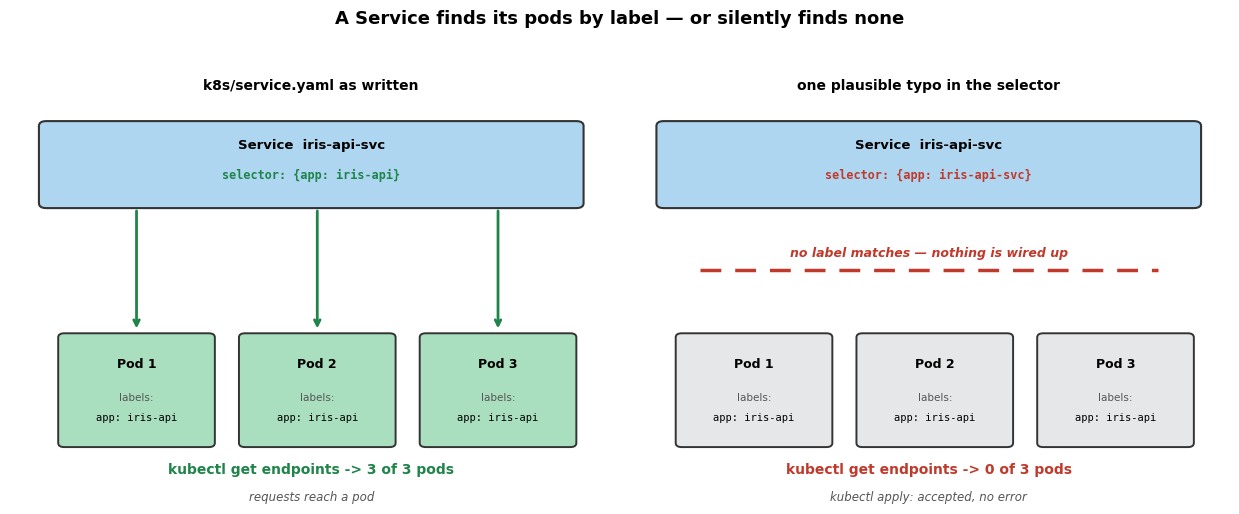

In [6]:
# WHAT: check, and then draw, the two links that hold the three manifests together:
#       the HPA's target name, and the Service's label selector over the pod labels.
# WHY: a selector that matches nothing is a SILENT failure — kubectl reports success
#      and the Service is simply empty. Seeing it beside the working case is the lesson.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml

with open("k8s/deployment.yaml") as fh:
    dep = yaml.safe_load(fh)
with open("k8s/service.yaml") as fh:
    svc = yaml.safe_load(fh)
with open("k8s/hpa.yaml") as fh:
    hpa = yaml.safe_load(fh)

POD_LABELS = dep["spec"]["template"]["metadata"]["labels"]   # what the pods carry
SVC_SELECTOR = svc["spec"]["selector"]                       # what the Service looks for
REPLICAS = dep["spec"]["replicas"]

# Kubernetes matches a Service to pods with plain subset matching on labels.
def endpoints(selector, pod_labels, replicas):
    """How many pods this selector would put behind the Service."""
    matches = all(pod_labels.get(k) == v for k, v in selector.items())
    return replicas if matches else 0


# Link 1: the HPA must name the Deployment exactly.
hpa_target = hpa["spec"]["scaleTargetRef"]["name"]
dep_name = dep["metadata"]["name"]
print(f"HPA scaleTargetRef.name = {hpa_target!r}   Deployment metadata.name = {dep_name!r}"
      f"   -> {'MATCH' if hpa_target == dep_name else 'NO MATCH — the HPA scales nothing'}")

# Link 2: the Service selector must be a subset of the pod labels.
good_ep = endpoints(SVC_SELECTOR, POD_LABELS, REPLICAS)
print(f"Service selector {SVC_SELECTOR} over pod labels {POD_LABELS}"
      f"   -> {good_ep} endpoint(s)")

# The typo: reaching for the SERVICE's own name instead of the app label. Very common.
typo_selector = {k: svc["metadata"]["name"] for k in SVC_SELECTOR}
bad_ep = endpoints(typo_selector, POD_LABELS, REPLICAS)
print(f"Typo selector    {typo_selector} over pod labels {POD_LABELS}"
      f"   -> {bad_ep} endpoint(s)")

GREEN, RED, BLUE = "#A9DFBF", "#F5B7B1", "#AED6F1"
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

for ax, (selector, n_ep, heading) in zip(axes, [
        (SVC_SELECTOR, good_ep, "k8s/service.yaml as written"),
        (typo_selector, bad_ep, "one plausible typo in the selector")]):
    ok = n_ep > 0
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

    sel_txt = ", ".join(f"{k}: {v}" for k, v in selector.items())
    ax.add_patch(mpatches.FancyBboxPatch((0.6, 7.4), 8.8, 1.9,
                                         boxstyle="round,pad=0.12",
                                         facecolor=BLUE, edgecolor="#333", linewidth=1.5))
    ax.text(5.0, 8.75, f'Service  {svc["metadata"]["name"]}', ha="center",
            fontsize=9.5, fontweight="bold")
    ax.text(5.0, 8.0, f"selector: {{{sel_txt}}}", ha="center", fontsize=8.5,
            family="monospace",
            color="#1E8449" if ok else "#C0392B", fontweight="bold")

    # The three pods the Deployment keeps running, with the labels they carry.
    pod_txt = ", ".join(f"{k}: {v}" for k, v in POD_LABELS.items())
    for p in range(REPLICAS):
        x = 0.9 + p * 3.0
        ax.add_patch(mpatches.FancyBboxPatch((x, 1.5), 2.4, 2.6,
                                             boxstyle="round,pad=0.1",
                                             facecolor=GREEN if ok else "#E5E7E9",
                                             edgecolor="#333", linewidth=1.4))
        ax.text(x + 1.2, 3.35, f"Pod {p + 1}", ha="center", fontsize=9, fontweight="bold")
        ax.text(x + 1.2, 2.55, "labels:", ha="center", fontsize=7.5, color="#555")
        ax.text(x + 1.2, 2.05, pod_txt, ha="center", fontsize=7.5, family="monospace")
        # An arrow only exists where the labels actually match.
        if ok:
            ax.annotate("", xy=(x + 1.2, 4.25), xytext=(x + 1.2, 7.28),
                        arrowprops=dict(arrowstyle="->", lw=2, color="#1E8449"))

    if not ok:
        ax.plot([1.2, 8.8], [5.75, 5.75], color="#C0392B", lw=2.5, linestyle=(0, (6, 4)))
        ax.text(5.0, 6.1, "no label matches — nothing is wired up", ha="center",
                fontsize=9, color="#C0392B", fontweight="bold", style="italic")

    ax.text(5.0, 0.75, f"kubectl get endpoints -> {n_ep} of {REPLICAS} pods",
            ha="center", fontsize=10, fontweight="bold",
            color="#1E8449" if ok else "#C0392B")
    ax.text(5.0, 0.1, "kubectl apply: accepted, no error"
            if not ok else "requests reach a pod",
            ha="center", fontsize=8.5, style="italic", color="#555")
    ax.set_title(heading, fontsize=10, fontweight="bold")

fig.suptitle("A Service finds its pods by label — or silently finds none",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


**Read the two panels.** They differ by one word in one line of YAML.

*Left.* The Service's `selector` and the pods' `labels` are the same key/value pair, so
three green arrows run from the pods up into the Service and `kubectl get endpoints`
reports **3 of 3**. Notice that the arrows are the only thing joining the two halves of the
picture: the Service does not know the Deployment exists, does not know the pods' names,
and does not know how many there are. It knows one label. That indirection is what lets a
rolling update swap every pod underneath it without the address changing.

*Right.* The selector now reads `iris-api-svc` — the Service's own name, which is the typo
people actually make — and the pods' labels still read `iris-api`. No arrow can be drawn.
The pods are greyed out not because anything is wrong with them but because, from the
Service's point of view, they do not exist. Endpoints: **0 of 3**.

The line at the bottom is the part to remember. The right-hand cluster is *healthy*: three
pods running, all probes passing, the Deployment perfectly satisfied, and `kubectl apply`
returned success. Only the traffic is gone. When a freshly-applied Service refuses every
connection, `kubectl get endpoints <svc>` is the first command to run — an empty list means
you are looking at this picture.

### Reading the HPA manifest as a curve

`minReplicas: 2`, `maxReplicas: 10`, `averageUtilization: 70` are three numbers in a file.
What they *do* is a control loop, and a control loop is easier to judge as a picture than
as YAML. The cell below reads the three numbers back out of `k8s/hpa.yaml` and plots the
autoscaler's own documented rule:

```text
desired = clamp( ceil( current_replicas * (u / u_target) ), minReplicas, maxReplicas )
```

where `u` is the average CPU utilisation across the pods, measured against each pod's CPU **request** (`100m`), not its limit. There is no cluster
running here — this is the arithmetic of the manifest, not a measurement.

From k8s/hpa.yaml: min=2, max=10, target utilisation=70%


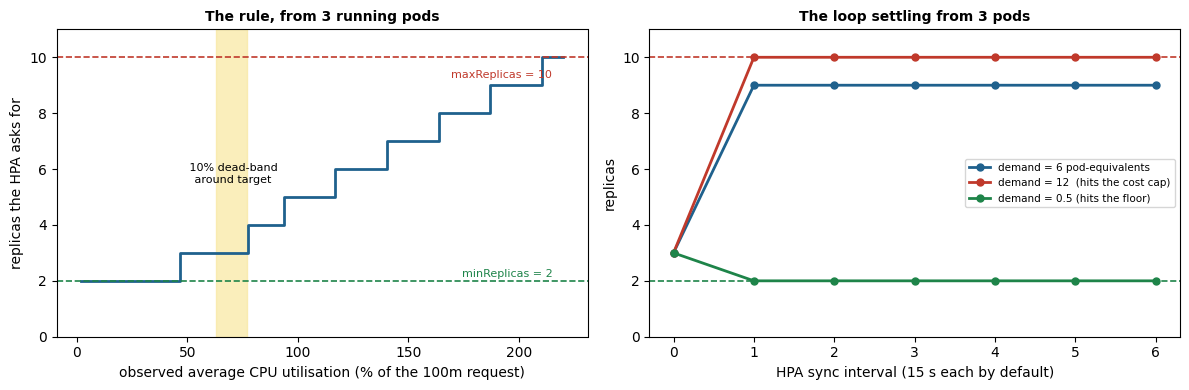


 demand | interval | replicas |  avg CPU | verdict
------------------------------------------------------------------------
    6.0 |        0 |        3 |    200% | will scale at the next interval
    6.0 |        1 |        9 |     67% | settled inside the dead-band
    6.0 |        6 |        9 |     67% | settled inside the dead-band
------------------------------------------------------------------------
   12.0 |        0 |        3 |    400% | will scale at the next interval
   12.0 |        1 |       10 |    120% | pinned at maxReplicas, over target
   12.0 |        6 |       10 |    120% | pinned at maxReplicas, over target
------------------------------------------------------------------------
    0.5 |        0 |        3 |     17% | will scale at the next interval
    0.5 |        1 |        2 |     25% | pinned at minReplicas, under target
    0.5 |        6 |        2 |     25% | pinned at minReplicas, under target
-------------------------------------------------------

In [7]:
# WHAT: plot the HPA rule from k8s/hpa.yaml — first as a response curve, then as
#       the control loop settling over successive 15-second sync intervals.
# WHY: min/max/target are easy to write and hard to reason about. Seeing where the
#      cost cap bites, and where the availability floor holds, is the whole lesson.
import math

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Read the numbers back out of the manifest we wrote — the figure and the YAML
# can never disagree, because they are the same three values.
with open("k8s/hpa.yaml") as fh:
    hpa = yaml.safe_load(fh)

MIN_R = hpa["spec"]["minReplicas"]
MAX_R = hpa["spec"]["maxReplicas"]
TARGET = hpa["spec"]["metrics"][0]["resource"]["target"]["averageUtilization"] / 100.0
TOLERANCE = 0.10   # Kubernetes ignores ratios within 10% of 1.0 (default --horizontal-pod-autoscaler-tolerance)

print(f"From k8s/hpa.yaml: min={MIN_R}, max={MAX_R}, target utilisation={TARGET:.0%}")


def desired_replicas(current: int, utilisation: float) -> int:
    """The upstream HPA algorithm: scale by the metric ratio, then clamp."""
    ratio = utilisation / TARGET
    if abs(ratio - 1.0) <= TOLERANCE:        # dead-band: do nothing
        return current
    return max(MIN_R, min(MAX_R, math.ceil(current * ratio)))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ---- Panel 1: the rule, evaluated from the current 3 replicas -------------------
u = np.linspace(0.02, 2.2, 400)
n_now = 3
ax1.step(u * 100, [desired_replicas(n_now, x) for x in u], where="post",
         color="#1F618D", lw=2)
ax1.axhline(MIN_R, ls="--", color="#1E8449", lw=1.2)
ax1.axhline(MAX_R, ls="--", color="#C0392B", lw=1.2)
ax1.axvspan((1 - TOLERANCE) * TARGET * 100, (1 + TOLERANCE) * TARGET * 100,
            color="#F9E79F", alpha=0.7, zorder=0)
ax1.text(TARGET * 100, MAX_R * 0.55, " 10% dead-band\n around target",
         fontsize=8, ha="center")
ax1.text(2.15 * 100, MIN_R + 0.15, f"minReplicas = {MIN_R}", fontsize=8,
         color="#1E8449", ha="right")
ax1.text(2.15 * 100, MAX_R - 0.75, f"maxReplicas = {MAX_R}", fontsize=8,
         color="#C0392B", ha="right")
ax1.set_xlabel("observed average CPU utilisation (% of the 100m request)")
ax1.set_ylabel("replicas the HPA asks for")
ax1.set_title(f"The rule, from {n_now} running pods", fontweight="bold", fontsize=10)
ax1.set_ylim(0, MAX_R + 1)

# ---- Panel 2: the loop settling, for three fixed CPU demands -------------------
# demand is total CPU consumed by the service, in multiples of one pod's request.
walks = [(6.0, "#1F618D", "demand = 6 pod-equivalents"),
         (12.0, "#C0392B", "demand = 12  (hits the cost cap)"),
         (0.5, "#1E8449", "demand = 0.5 (hits the floor)")]
STEPS = 6
table = []
for demand, colour, label in walks:
    n, traj, utils = 3, [3], []
    for _ in range(STEPS):
        util = demand / n
        utils.append(util)
        n = desired_replicas(n, util)
        traj.append(n)
    utils.append(demand / n)
    ax2.plot(range(len(traj)), traj, "o-", color=colour, lw=2, ms=5, label=label)
    table.append((demand, traj, utils))

ax2.axhline(MIN_R, ls="--", color="#1E8449", lw=1.2)
ax2.axhline(MAX_R, ls="--", color="#C0392B", lw=1.2)
ax2.set_xlabel("HPA sync interval (15 s each by default)")
ax2.set_ylabel("replicas")
ax2.set_title("The loop settling from 3 pods", fontweight="bold", fontsize=10)
ax2.set_ylim(0, MAX_R + 1)
ax2.legend(fontsize=7.5, loc="center right")

plt.tight_layout()
plt.show()

# The step table behind panel 2 — replicas and the utilisation that produced them.
print()
print(f"{'demand':>7} | {'interval':>8} | {'replicas':>8} | {'avg CPU':>8} | verdict")
print("-" * 72)
for demand, traj, utils in table:
    for i in (0, 1, STEPS):
        settled = abs(utils[i] / TARGET - 1.0) <= TOLERANCE
        if traj[i] == MAX_R and not settled:
            verdict = "pinned at maxReplicas, over target"
        elif traj[i] == MIN_R and not settled:
            verdict = "pinned at minReplicas, under target"
        elif settled:
            verdict = "settled inside the dead-band"
        else:
            verdict = "will scale at the next interval"
        print(f"{demand:>7.1f} | {i:>8} | {traj[i]:>8} | {utils[i]:>7.0%} | {verdict}")
    print("-" * 72)


**Read the two panels.**

*Left — the rule.* The response is a staircase, not a slope: the HPA can only ask for whole
pods, so utilisation has to move a long way before the count changes. The yellow band is the
10% dead-band around the 70% target, where the autoscaler deliberately does nothing — that
is what stops it oscillating. Outside the band the staircase runs until it hits one of the two
dashed lines, and there it stops: 2 pods no matter how idle the service is, 10 pods no matter
how loaded.

*Right — the loop.* All three walks settle in **one** sync interval, because the HPA scales by
a ratio rather than one pod at a time. The blue walk lands at 9 pods and stays: utilisation is
back inside the dead-band, so it stops. The red walk asks for 18, gets 10, and stays pinned —
and the step table prints its average CPU at **120%**, above the 70% target. That is the
important thing to see: when `maxReplicas` binds, the autoscaler stops protecting latency and
starts protecting your bill; nothing in the manifest tells you which one you wanted. The green
walk hits the floor and holds 2 pods at 25% CPU — availability you are paying for on purpose.

One honesty note: real scale-*down* is slower than this picture. Kubernetes applies a
five-minute stabilisation window before removing pods, so the green walk would drop in one
step here but take minutes on a cluster.

---
## Section 4 — kubectl Commands

These cells run `kubectl` via `subprocess`. If `kubectl` and a cluster are not available, the expected output is shown so you know what to look for in a real environment.


In [8]:
# Helper used by every kubectl cell below. It is honest about all three cases:
#   1. kubectl installed AND a cluster answers -> run for real, show real output
#   2. kubectl not installed                   -> FileNotFoundError
#   3. kubectl present but NO cluster running  -> command fails ("connection refused")
# Cases 2 and 3 print the expected output instead, clearly labeled — no raw
# error walls, no pretending a command succeeded.
import subprocess

def run_kubectl(args, expected_output=None, timeout=30):
    """Run a kubectl command; print a labeled teaching fallback if it cannot run."""
    cmd = ["kubectl"] + args
    print("Command:", " ".join(cmd))
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
        if result.returncode == 0:
            # Real cluster answered: show the genuine output
            print(result.stdout or "(no output)")
            print()
            return True
        print("(kubectl is installed but no cluster is reachable — expected output:)")
    except FileNotFoundError:
        print("(kubectl not installed — expected output:)")
    except subprocess.TimeoutExpired:
        print("(timed out — expected output:)")
    if expected_output:
        print(expected_output)
    print()
    return False

# Apply all three manifests at once — Deployment, Service, and HPA
run_kubectl(
    ["apply", "-f", "k8s/"],
    expected_output=(
        "deployment.apps/iris-api created\n"
        "service/iris-api-svc created\n"
        "horizontalpodautoscaler.autoscaling/iris-api-hpa created"
    )
)


Command: kubectl apply -f k8s/


(kubectl is installed but no cluster is reachable — expected output:)
deployment.apps/iris-api created
service/iris-api-svc created
horizontalpodautoscaler.autoscaling/iris-api-hpa created



False

In [9]:
# Inspect the running deployment (reuses the run_kubectl helper defined above)

# List pods — after ~30s all should be Running
run_kubectl(
    ["get", "pods", "-l", "app=iris-api"],
    expected_output=(
        "NAME                        READY   STATUS    RESTARTS   AGE\n"
        "iris-api-7d4f9c8b5-xkp2q   1/1     Running   0          45s\n"
        "iris-api-7d4f9c8b5-mn7rj   1/1     Running   0          45s\n"
        "iris-api-7d4f9c8b5-v9tw1   1/1     Running   0          45s"
    )
)

# Describe one pod — shows probes, resource limits, recent events
run_kubectl(
    ["describe", "pod", "-l", "app=iris-api"],
    expected_output=(
        "Name:         iris-api-7d4f9c8b5-xkp2q\n"
        "Liveness:   http-get http://:8000/health delay=5s timeout=1s period=10s\n"
        "Readiness:  http-get http://:8000/health delay=3s timeout=1s period=5s\n"
        "Events:\n"
        "  Normal  Scheduled  pod was successfully assigned to node\n"
        "  Normal  Pulled     Container image pulled\n"
        "  Normal  Started    Started container iris-api"
    )
)

# View recent logs from all pods with the app=iris-api label
run_kubectl(
    ["logs", "-l", "app=iris-api", "--tail=5"],
    expected_output=(
        "INFO:     Application startup complete.\n"
        "INFO:     Uvicorn running on http://0.0.0.0:8000"
    )
)

# Show the Service and its external IP
run_kubectl(
    ["get", "svc", "iris-api-svc"],
    expected_output=(
        "NAME           TYPE           CLUSTER-IP     EXTERNAL-IP     PORT(S)       AGE\n"
        "iris-api-svc   LoadBalancer   10.96.45.123   34.102.136.180  80:31234/TCP  2m"
    )
)


Command: kubectl get pods -l app=iris-api


(kubectl is installed but no cluster is reachable — expected output:)
NAME                        READY   STATUS    RESTARTS   AGE
iris-api-7d4f9c8b5-xkp2q   1/1     Running   0          45s
iris-api-7d4f9c8b5-mn7rj   1/1     Running   0          45s
iris-api-7d4f9c8b5-v9tw1   1/1     Running   0          45s

Command: kubectl describe pod -l app=iris-api
(kubectl is installed but no cluster is reachable — expected output:)
Name:         iris-api-7d4f9c8b5-xkp2q
Liveness:   http-get http://:8000/health delay=5s timeout=1s period=10s
Readiness:  http-get http://:8000/health delay=3s timeout=1s period=5s
Events:
  Normal  Scheduled  pod was successfully assigned to node
  Normal  Pulled     Container image pulled
  Normal  Started    Started container iris-api

Command: kubectl logs -l app=iris-api --tail=5


(kubectl is installed but no cluster is reachable — expected output:)
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000

Command: kubectl get svc iris-api-svc


(kubectl is installed but no cluster is reachable — expected output:)
NAME           TYPE           CLUSTER-IP     EXTERNAL-IP     PORT(S)       AGE
iris-api-svc   LoadBalancer   10.96.45.123   34.102.136.180  80:31234/TCP  2m



False

---
## Section 5 — Rolling Update: Deploying a New Model Version

When you train a new model and build `iris-api:v2`, you update the image tag. Kubernetes replaces pods one at a time, keeping the service available throughout.

The `RollingUpdate` strategy in the Deployment controls this:
- `maxUnavailable: 1` — at most 1 pod is down at any moment (2 of 3 always serve traffic)
- `maxSurge: 1` — at most 1 extra pod exists temporarily (up to 4 pods during the rollout)

Readiness probes are critical here: a new pod only receives traffic after its readiness probe passes. If the new image is broken and the probe never passes, the rollout stalls — and the old pods stay up.


In [10]:
# Roll out a new model version by updating the image tag in place
# (no need to edit YAML for a single-field change)
run_kubectl(
    ["set", "image", "deployment/iris-api", "iris-api=iris-api:v2"],
    expected_output=(
        "deployment.apps/iris-api image updated\n"
        "\n"
        "Kubernetes then performs a rolling update:\n"
        "  1. Starts a new pod with iris-api:v2\n"
        "  2. Waits for its readiness probe to pass\n"
        "  3. Removes one old iris-api:v1 pod\n"
        "  4. Repeats until all 3 pods run v2\n"
        "  Traffic never drops to 0 pods."
    )
)


Command: kubectl set image deployment/iris-api iris-api=iris-api:v2
(kubectl is installed but no cluster is reachable — expected output:)
deployment.apps/iris-api image updated

Kubernetes then performs a rolling update:
  1. Starts a new pod with iris-api:v2
  2. Waits for its readiness probe to pass
  3. Removes one old iris-api:v1 pod
  4. Repeats until all 3 pods run v2
  Traffic never drops to 0 pods.



False

In [11]:
# Watch the rolling update progress until it completes
# rollout status blocks until every new pod is Ready — the safe moment to declare success.
run_kubectl(
    ["rollout", "status", "deployment/iris-api"],
    expected_output=(
        "Waiting for deployment iris-api rollout to finish: 1 out of 3 new replicas updated...\n"
        "Waiting for deployment iris-api rollout to finish: 2 out of 3 new replicas updated...\n"
        "deployment iris-api successfully rolled out"
    ),
    timeout=60,
)

Command: kubectl rollout status deployment/iris-api


(kubectl is installed but no cluster is reachable — expected output:)
Waiting for deployment iris-api rollout to finish: 1 out of 3 new replicas updated...
Waiting for deployment iris-api rollout to finish: 2 out of 3 new replicas updated...
deployment iris-api successfully rolled out



False

### Storyboard: what those three strategies do to the fleet

`kubectl rollout status` printed three lines of text. Underneath those lines, pods are being
created, gated on readiness, and terminated in a specific order — and the order is the entire
safety argument. The cell below reads `replicas`, `maxSurge` and `maxUnavailable` back out of
`k8s/deployment.yaml` and draws the fleet at each step of three strategies side by side.

No cluster is running here, so this is a storyboard of the declared policy, not a recording of
one. Every number in it comes from the manifest above.

From k8s/deployment.yaml: replicas=3, maxSurge=1, maxUnavailable=1


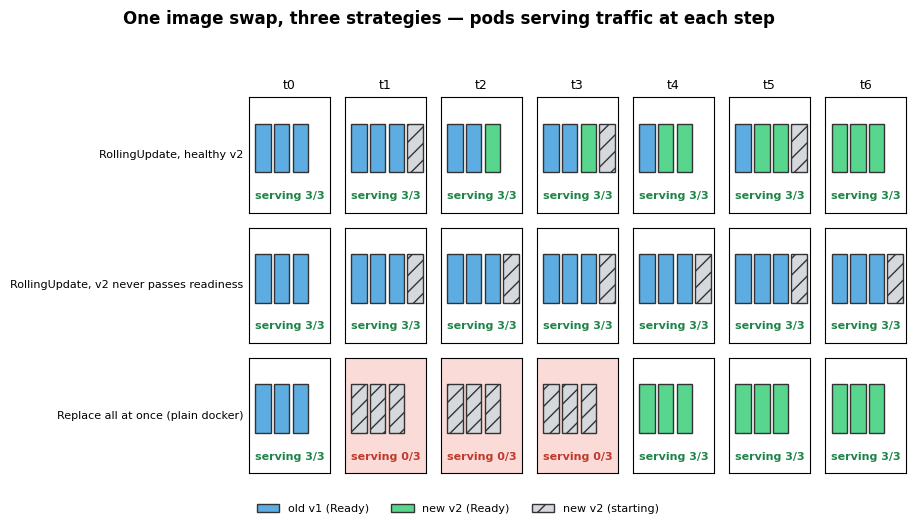


strategy                                      t0    t1    t2    t3    t4    t5    t6   min
------------------------------------------------------------------------------------------
RollingUpdate, healthy v2                      3     3     3     3     3     3     3     3
RollingUpdate, v2 never passes readiness       3     3     3     3     3     3     3     3
Replace all at once (plain docker)             3     0     0     0     3     3     3     0


In [12]:
# WHAT: draw the pod fleet at each step of three update strategies, as a frame grid.
# WHY: "traffic never drops to zero" is a claim about a sequence. A sequence is what
#      you have to see to believe it — and to see what the broken-image case does.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml

# Read the rollout policy back out of the manifest we wrote earlier.
with open("k8s/deployment.yaml") as fh:
    dep = yaml.safe_load(fh)

REPLICAS = dep["spec"]["replicas"]
RU = dep["spec"]["strategy"]["rollingUpdate"]
MAX_SURGE, MAX_UNAVAIL = RU["maxSurge"], RU["maxUnavailable"]
print(f"From k8s/deployment.yaml: replicas={REPLICAS}, "
      f"maxSurge={MAX_SURGE}, maxUnavailable={MAX_UNAVAIL}")

# Each frame is (old_ready, new_ready, new_starting). Pods that serve traffic are the
# ready ones; a starting pod is in the fleet but out of the load balancer.
OLD, NEW, WARM = "old v1 (Ready)", "new v2 (Ready)", "new v2 (starting)"


def rolling(replicas, surge, healthy=True):
    """Surge-first, readiness-gated replacement — one pod at a time."""
    frames = [(replicas, 0, 0)]
    if not healthy:
        # The new pod starts but its readiness probe never passes: the rollout stalls
        # here and the old pods keep every request.
        return frames + [(replicas, 0, 1)] * 6
    old, new = replicas, 0
    while old > 0:
        # Surge one extra pod: the fleet is now replicas + maxSurge, but the newcomer
        # is not in the load balancer until its readiness probe passes.
        frames.append((old, new, surge))
        # Readiness passes and one old pod is drained and removed in the same beat.
        new, old = new + surge, old - surge
        frames.append((old, new, 0))
    return frames


def all_at_once(replicas):
    """What `docker stop && docker run` does: every pod replaced in one move."""
    return [(replicas, 0, 0), (0, 0, replicas), (0, 0, replicas),
            (0, 0, replicas), (0, replicas, 0), (0, replicas, 0), (0, replicas, 0)]


strategies = [
    ("RollingUpdate, healthy v2", rolling(REPLICAS, MAX_SURGE, healthy=True)),
    ("RollingUpdate, v2 never passes readiness", rolling(REPLICAS, MAX_SURGE, healthy=False)),
    ("Replace all at once (plain docker)", all_at_once(REPLICAS)),
]
n_frames = min(len(f) for _, f in strategies)
n_frames = min(n_frames, 8)                        # keep the grid readable

COLOURS = {OLD: "#5DADE2", NEW: "#58D68D", WARM: "#D5D8DC"}
fig, axes = plt.subplots(len(strategies), n_frames,
                         figsize=(1.35 * n_frames, 1.5 * len(strategies) + 0.7))

for row, (name, frames) in enumerate(strategies):
    for col in range(n_frames):
        ax = axes[row, col]
        old_r, new_r, warm = frames[col]
        serving = old_r + new_r
        pods = [OLD] * old_r + [NEW] * new_r + [WARM] * warm
        for k, kind in enumerate(pods):
            ax.add_patch(mpatches.Rectangle(
                (0.08 + 0.23 * k, 0.35), 0.19, 0.42,
                facecolor=COLOURS[kind], edgecolor="#333",
                hatch="//" if kind is WARM else None))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        # The one number that matters: how many pods are in the load balancer.
        ax.text(0.5, 0.12, f"serving {serving}/{REPLICAS}", ha="center", fontsize=8,
                fontweight="bold", color="#C0392B" if serving == 0 else "#1E8449")
        if serving == 0:
            ax.set_facecolor("#FADBD8")
        if row == 0:
            ax.set_title(f"t{col}", fontsize=9)
    axes[row, 0].set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")

handles = [mpatches.Patch(facecolor=c, edgecolor="#333", label=k,
                          hatch="//" if k is WARM else None) for k, c in COLOURS.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=8, frameon=False)
fig.suptitle("One image swap, three strategies — pods serving traffic at each step",
             fontweight="bold", fontsize=12)
plt.tight_layout(rect=(0.02, 0.06, 1, 0.94))
plt.show()

# The same storyboard as a table, so the numbers are readable without the picture.
print()
header = "strategy".ljust(42) + "".join(f"t{i}".rjust(6) for i in range(n_frames)) + "   min"
print(header)
print("-" * len(header))
for name, frames in strategies:
    serving = [o + n for o, n, _ in frames[:n_frames]]
    print(name.ljust(42) + "".join(str(s).rjust(6) for s in serving)
          + f"{min(serving):>6}")


**Read the grid, row by row.**

*Row 1 — RollingUpdate with a healthy `v2`.* The bottom line never moves: **3 of 3 pods are
serving traffic in every single frame**. Look at what changes instead — at `t1`, `t3` and `t5`
the fleet holds *four* pods, three blue-or-green ready ones plus a hatched newcomer that is
started but not yet in the load balancer. That fourth pod is `maxSurge: 1`, and renting it for a
few seconds is exactly what buys the zero-downtime property. An old pod is only drained after a
new one has passed its probe, so by `t6` every pod is green and no request was ever dropped.
(With `maxSurge: 0` the controller would have to remove before it adds, and the row would dip to
2 — which `maxUnavailable: 1` still permits.)

*Row 2 — the same rollout with a broken `v2`.* The readiness probe never passes, so the
storyboard freezes: one hatched pod forever, three old pods still taking every request. The
rollout does not complete and it does not take the service down. That is the safety property —
and its limit: the probe only checks that the process answers `/health`, so a model that starts
perfectly and returns nonsense sails straight through it.

*Row 3 — replace all at once.* Three consecutive frames shaded red, **0 of 3 serving**. That is
what `docker stop && docker run` costs you, and it is the shape of the CrowdStrike failure at the
top of this notebook: one change, everything at once, nothing healthy left to roll back onto.

---
## Section 6 — Rollback

If the new version has a bug (degraded accuracy, crashes on real inputs, failed smoke tests), you roll back to the previous version with one command. Kubernetes stores rollout history automatically.


In [13]:
# Rollback workflow (reuses the run_kubectl helper defined above)

# View rollout history — every revision the Deployment has been through
run_kubectl(
    ["rollout", "history", "deployment/iris-api"],
    expected_output=(
        "REVISION  CHANGE-CAUSE\n"
        "1         <none>   (iris-api:v1)\n"
        "2         <none>   (iris-api:v2)"
    )
)

# Rollback to the previous revision — one command, zero downtime
run_kubectl(
    ["rollout", "undo", "deployment/iris-api"],
    expected_output="deployment.apps/iris-api rolled back"
)

# Verify pods are running v1 again
run_kubectl(
    ["get", "pods", "-l", "app=iris-api"],
    expected_output=(
        "NAME                        READY   STATUS    RESTARTS   AGE\n"
        "iris-api-7d4f9c8b5-ab1cd   1/1     Running   0          30s\n"
        "iris-api-7d4f9c8b5-ef2gh   1/1     Running   0          25s\n"
        "iris-api-7d4f9c8b5-ij3kl   1/1     Running   0          20s"
    )
)


Command: kubectl rollout history deployment/iris-api


(kubectl is installed but no cluster is reachable — expected output:)
REVISION  CHANGE-CAUSE
1         <none>   (iris-api:v1)
2         <none>   (iris-api:v2)

Command: kubectl rollout undo deployment/iris-api
(kubectl is installed but no cluster is reachable — expected output:)
deployment.apps/iris-api rolled back

Command: kubectl get pods -l app=iris-api


(kubectl is installed but no cluster is reachable — expected output:)
NAME                        READY   STATUS    RESTARTS   AGE
iris-api-7d4f9c8b5-ab1cd   1/1     Running   0          30s
iris-api-7d4f9c8b5-ef2gh   1/1     Running   0          25s
iris-api-7d4f9c8b5-ij3kl   1/1     Running   0          20s



False

## 💬 Discuss

Read what the rollout and rollback cells describe together: a new image goes out one Pod at a time, **each new Pod receives traffic only after its readiness probe passes**, and `kubectl rollout undo` returns to the previous revision because Kubernetes kept the history.

1. The rollout stalls if the new image's readiness probe never passes — and the old Pods keep serving. That is the safety property. What class of bad model does it catch, and what class does it completely miss? (A model that starts fine and returns nonsense is the case to think about.)
2. CrowdStrike's revert took 78 minutes and still left machines broken. Translate that into your Deployment: what would have to be true about your model service for `rollout undo` to be *insufficient*? Name at least one thing your service could do that a rollback would not reverse.
3. Kubernetes keeps rollout history so `undo` works. How many revisions should it keep, and what is the cost of keeping more? Then ask the harder version: what has to still exist in your image registry for revision 1 to actually be startable six months later?

---
## Summary

Kubernetes gives you three things that Docker alone cannot:

1. **Self-healing** — Deployments with liveness probes automatically restart crashed pods. The desired replica count is always reconciled.
2. **Scaling** — The HPA adds and removes pods based on real traffic load, so you pay for what you use.
3. **Zero-downtime updates** — Rolling update strategy swaps pods one at a time. Readiness probes ensure traffic is never routed to an unready pod. Rollback is one command.

The workflow: write YAML manifests → `kubectl apply` → Kubernetes manages the rest.

**Next:** Notebook 03 compares AWS SageMaker, Azure ML, and GCP Vertex AI — so you know when to use self-managed K8s vs. a fully managed ML platform.


---
## Self-Check Questions

Answer without scrolling, then re-read the relevant section to check.

1. **What is the difference between a liveness probe and a readiness probe?**
   *(Hint: one triggers a restart; the other controls whether traffic is sent to the pod.)*

2. **What happens when you run `kubectl apply` on a Deployment that is already deployed with the same image?**
   *(Hint: Kubernetes is declarative — it computes a diff between desired and actual state.)*

3. **If a Deployment has 3 replicas and 1 pod crashes, what does Kubernetes do?**
   *(Hint: trace what happens after a liveness probe fails three times.)*


## ⚠️ Where this breaks

- **A rolling update is not a canary.** `maxSurge: 1, maxUnavailable: 1` replaces Pods steadily until every Pod runs the new image. If the new model is *healthy but wrong*, the rollout completes perfectly and 100% of users get the wrong answers. Kubernetes gates on process health, never on prediction quality. Traffic-percentage gating on a *measured* metric is a separate mechanism (Unit 5, notebook 07).
- **Rollback restores a spec, not a state.** `rollout undo` re-applies the previous image tag. It does not un-send predictions, un-write database rows, or repair clients that already cached a bad response — and, as CrowdStrike showed at the operating-system level, it cannot help anything that has lost the ability to receive updates. Ask what your service does that is irreversible before you rely on rollback as your safety net.
- **`rollout undo` needs the old image to still exist.** Registry retention policies delete old tags. A Deployment can reference `iris-api:v1` in its history and be unable to start it because the image was garbage-collected. Pin retention for anything you might roll back to.
- **The assumption that must hold:** the readiness probe means something. A probe that returns 200 as soon as the HTTP server binds — before the model is loaded — actively causes the outage it was meant to prevent, by routing live traffic into a Pod that cannot answer. Make it check the model, not the port.
- **Nothing here ran against a cluster.** Every `kubectl` cell printed expected output. You have not watched a rollout stall, or seen `CrashLoopBackOff`, or debugged an `OOMKilled` Pod — and those are the three things you will actually spend your time on. Minikube or Kind on a laptop is the cheapest way to close that gap.
- **The cheaper alternative.** One model, one region, predictable traffic, no team of platform engineers: a managed container service that runs your image behind a load balancer gives you self-healing and rolling updates without a cluster to operate. Kubernetes is worth its complexity when you are running many services, not one.

## 🔭 State of the field (2026)

Deployment, Service and HorizontalPodAutoscaler are still how ML containers are run and scaled in
2026: the cloud-native LLM serving systems published since 2025 are built on exactly these
Kubernetes objects, using containerization, microservices and dynamic scheduling to absorb workload
swings (Xu et al., 2025, arXiv:2507.18007). What changed is the *signal*, not the objects. For a
scikit-learn API like this one, `averageUtilization: 70` on CPU is the right knob, because the work
per request really is CPU work; for a generative model it is not, because serving splits into
separate prefill and decode pools on GPUs. A production study of that architecture reports that
"traditional autoscalers fall short" and replaces per-pod resource utilisation with a single
production-derived metric that scales both pools together — worth 26.6 percentage points of average
GPU utilisation across tens of thousands of GPUs (Li et al., 2025, arXiv:2508.19559).

Learn this version first, because it is the mechanism the newer one is built on. A coordinated
autoscaler still finishes by handing a controller a replica count, and that is the controller you
just watched reconcile; readiness probes are still what keep traffic away from a Pod that cannot
answer, and `kubectl rollout undo` is still the recovery path. Change the metric block in
`hpa.yaml` and you have the 2026 design — which is why the official plan examines the objects and
the rollout, not the choice of metric.

## 📚 References

1. Verma, A., Pedrosa, L., Korupolu, M. R., Oppenheimer, D., Tune, E., & Wilkes, J. (2015). *Large-Scale Cluster Management at Google with Borg*. EuroSys. <https://research.google/pubs/large-scale-cluster-management-at-google-with-borg/>
2. Burns, B., Grant, B., Oppenheimer, D., Brewer, E., & Wilkes, J. (2016). *Borg, Omega, and Kubernetes*. ACM Queue 14(1). <https://research.google/pubs/borg-omega-and-kubernetes/>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Xu, M., Liao, J., Wu, J., He, Y., Ye, K., & Xu, C. (2025). *Cloud Native System for LLM Inference Serving*. arXiv:2507.18007. <https://arxiv.org/abs/2507.18007>
5. Li, R., Du, R., Chu, Z., et al. (2025). *Taming the Chaos: Coordinated Autoscaling for Heterogeneous and Disaggregated LLM Inference*. arXiv:2508.19559. <https://arxiv.org/abs/2508.19559>